<a href="https://colab.research.google.com/github/ManasAyyalaraju/personal-finance-health-predictor/blob/main/notebooks/02_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATA PREPROCESSING & CLEANING

Importing Libraries and Data Sets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.chdir('/content/drive/MyDrive/Personal_Finance_ML_Project')

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

german_credit = pd.read_csv('data/raw/german_credit_data.csv')
lending_club = pd.read_csv('data/raw/accepted/accepted_2007_to_2018Q4.csv',nrows=100000, low_memory=False)
fraud_data = pd.read_csv('data/raw/creditcard.csv')

# Missing Data Analysis

German Credit Dataset


 Columns with Missing Data:
          Column  Missing_Count  Missing_Percentage Data_Type
Checking account            394                39.4    object
 Saving accounts            183                18.3    object


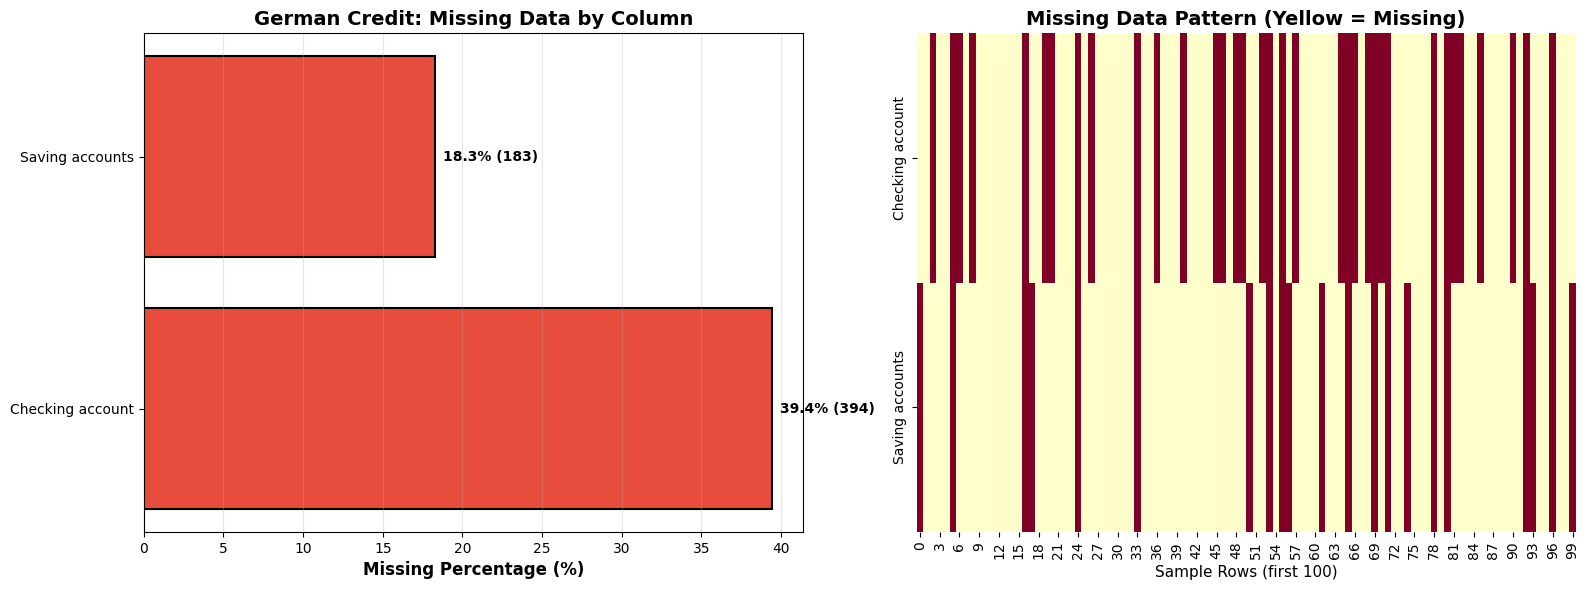


 Summary:
   Total rows: 1,000
   Total columns: 10
   Columns with missing data: 2
   Total missing values: 577


In [10]:
# Count missing values
missing_german = german_credit.isnull().sum()
missing_pct_german = (missing_german / len(german_credit)) * 100

# Create summary dataframe
missing_summary_german = pd.DataFrame({
    'Column': missing_german.index,
    'Missing_Count': missing_german.values,
    'Missing_Percentage': missing_pct_german.values,
    'Data_Type': german_credit.dtypes.values
}).sort_values('Missing_Percentage', ascending=False)

# Display only columns with missing data
missing_cols_german = missing_summary_german[missing_summary_german['Missing_Count'] > 0]

if len(missing_cols_german) > 0:
    print("\n Columns with Missing Data:")
    print(missing_cols_german.to_string(index=False))

    # Visualize missing data
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    axes[0].barh(missing_cols_german['Column'], missing_cols_german['Missing_Percentage'],
                 color='#e74c3c', edgecolor='black', linewidth=1.5)
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
    axes[0].set_title('German Credit: Missing Data by Column', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3, axis='x')

    # Add value labels
    for i, (col, pct, count) in enumerate(zip(missing_cols_german['Column'],
                                               missing_cols_german['Missing_Percentage'],
                                               missing_cols_german['Missing_Count'])):
        axes[0].text(pct + 0.5, i, f'{pct:.1f}% ({int(count)})',
                    va='center', fontweight='bold', fontsize=10)

    # Heatmap showing pattern
    axes[1].set_title('Missing Data Pattern (Yellow = Missing)', fontsize=14, fontweight='bold')
    missing_matrix = german_credit[missing_cols_german['Column']].isnull()
    sns.heatmap(missing_matrix.head(100).T, cmap='YlOrRd', cbar=False,
                yticklabels=missing_cols_german['Column'], ax=axes[1])
    axes[1].set_xlabel('Sample Rows (first 100)', fontsize=11)

    plt.tight_layout()
    plt.show()

else:
    print("\n✅ No missing data found in German Credit dataset!")

# Summary statistics
print(f"\n Summary:")
print(f"   Total rows: {len(german_credit):,}")
print(f"   Total columns: {len(german_credit.columns)}")
print(f"   Columns with missing data: {len(missing_cols_german)}")
print(f"   Total missing values: {missing_german.sum():,}")

Lending Club Dataset


 Top 20 Columns with Missing Data (out of 20 total):
                                    Column  Missing_Count  Missing_Percentage Data_Type
                                 member_id         100000             100.000   float64
                     sec_app_num_rev_accts         100000             100.000   float64
                       sec_app_open_act_il         100000             100.000   float64
                    sec_app_inq_last_6mths         100000             100.000   float64
                          sec_app_open_acc         100000             100.000   float64
                          sec_app_mort_acc         100000             100.000   float64
       sec_app_mths_since_last_major_derog         100000             100.000   float64
        sec_app_collections_12_mths_ex_med         100000             100.000   float64
          sec_app_chargeoff_within_12_mths         100000             100.000   float64
                    sec_app_fico_range_low         100000         

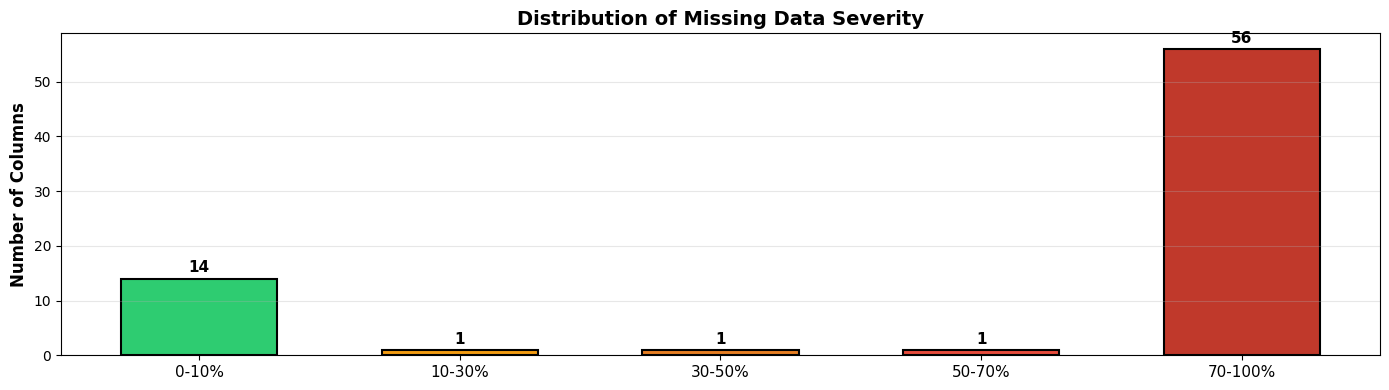


 Summary:
   Total rows: 100,000
   Total columns: 151
   Columns with missing data: 73
   Total missing values: 5,336,952
   Overall missing rate: 35.34%


In [20]:
# Count missing values
missing_lending = lending_club.isnull().sum()
missing_pct_lending = (missing_lending / len(lending_club)) * 100

# Create summary dataframe
missing_summary_lending = pd.DataFrame({
    'Column': missing_lending.index,
    'Missing_Count': missing_lending.values,
    'Missing_Percentage': missing_pct_lending.values,
    'Data_Type': lending_club.dtypes.values
}).sort_values('Missing_Percentage', ascending=False)

# Display top 20 columns with most missing data
missing_cols_lending = missing_summary_lending[missing_summary_lending['Missing_Count'] > 0].head(20)

print(f"\n Top 20 Columns with Missing Data (out of {len(missing_cols_lending)} total):")
print(missing_cols_lending.to_string(index=False))

# Visualize missing data
fig, axes = plt.subplots(1, 1, figsize=(14, 4))

# Missing data by percentage category
missing_categories = pd.cut(missing_summary_lending['Missing_Percentage'],
                            bins=[0, 10, 30, 50, 70, 100],
                            labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-100%'])
category_counts = missing_categories.value_counts().sort_index()

colors_cat = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
axes.bar(range(len(category_counts)), category_counts.values,
            color=colors_cat, edgecolor='black', linewidth=1.5, width=0.6)
axes.set_xticks(range(len(category_counts)))
axes.set_xticklabels(category_counts.index, fontsize=11)
axes.set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes.set_title('Distribution of Missing Data Severity', fontsize=14, fontweight='bold')
axes.grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(category_counts.values):
    axes.text(i, v + max(category_counts)*0.02, str(v),
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Summary statistics
total_missing_cols = (missing_lending > 0).sum()
print(f"\n Summary:")
print(f"   Total rows: {len(lending_club):,}")
print(f"   Total columns: {len(lending_club.columns)}")
print(f"   Columns with missing data: {total_missing_cols}")
print(f"   Total missing values: {missing_lending.sum():,}")
print(f"   Overall missing rate: {(missing_lending.sum() / (len(lending_club) * len(lending_club.columns))) * 100:.2f}%")

Fraud Dataset

In [21]:

# Count missing values
missing_fraud = fraud_data.isnull().sum()
missing_pct_fraud = (missing_fraud / len(fraud_data)) * 100

# Create summary dataframe
missing_summary_fraud = pd.DataFrame({
    'Column': missing_fraud.index,
    'Missing_Count': missing_fraud.values,
    'Missing_Percentage': missing_pct_fraud.values
}).sort_values('Missing_Percentage', ascending=False)

# Display columns with missing data
missing_cols_fraud = missing_summary_fraud[missing_summary_fraud['Missing_Count'] > 0]

if len(missing_cols_fraud) > 0:
    print("\n📊 Columns with Missing Data:")
    print(missing_cols_fraud.to_string(index=False))
else:
    print("\n✅ Perfect! No missing data in Credit Card Fraud dataset!")
    print("   This is expected - transaction data is typically complete.")

print(f"\n📈 Summary:")
print(f"   Total rows: {len(fraud_data):,}")
print(f"   Total columns: {len(fraud_data.columns)}")
print(f"   Total missing values: {missing_fraud.sum():,}")


✅ Perfect! No missing data in Credit Card Fraud dataset!
   This is expected - transaction data is typically complete.

📈 Summary:
   Total rows: 284,807
   Total columns: 31
   Total missing values: 0


Missing Data Strategy

Decision Rules:
1. More than 70% missing → DROP column (not informative)"
2. 30-70% missing → Analyze pattern, impute or drop"
3. Less than 30% missing → Impute (mean/median/mode)"
4. Categorical → Mode or 'Unknown'"
5. Numerical → Median (robust to outliers)"